In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Thiết lập phong cách đồ thị chuẩn
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Nạp tập dữ liệu
data_path = '../data/Womens Clothing E-Commerce Reviews.csv'
if not os.path.exists(data_path):
    data_path = '../../DATA/Womens Clothing E-Commerce Reviews.csv'

df = pd.read_csv(data_path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"-> Nạp thành công dữ liệu từ: {data_path}")
print(f"-> Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")

-> Nạp thành công dữ liệu từ: ../data/Womens Clothing E-Commerce Reviews.csv
-> Kích thước tập dữ liệu: 23486 dòng, 10 cột


In [3]:
print("=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===")
display(df.head())

print("\n=== THÔNG TIN KIỂU DỮ LIỆU VÀ BỘ NHỚ (INFO) ===")
df.info()

print("\n=== PHÂN PHỐI BIẾN MỤC TIÊU (RECOMMENDED IND) ===")
print(df['Recommended IND'].value_counts())

print("\n=== THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG SỐ ===")
display(df.describe())

=== 5 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU ===


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



=== THÔNG TIN KIỂU DỮ LIỆU VÀ BỘ NHỚ (INFO) ===
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB

=== PHÂN PHỐI BIẾN MỤC TIÊU (RECOMMENDED IND) ===
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

=== THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG SỐ ===


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [4]:
print("=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) THEO TỪNG CỘT ===")
print(df.isnull().sum())

# 1. Điền chuỗi rỗng cho các cột văn bản (Title, Review Text)
df['Title'] = df['Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')

# 2. Điền nhãn 'Unknown' cho các biến phân loại bị thiếu
df['Division Name'] = df['Division Name'].fillna('Unknown')
df['Department Name'] = df['Department Name'].fillna('Unknown')
df['Class Name'] = df['Class Name'].fillna('Unknown')

# 3. Chỉ giữ các mẫu có nội dung đánh giá (Title hoặc Review Text có chữ)
df['Full_Review'] = (df['Title'] + ' ' + df['Review Text']).str.strip()
df_clean = df[df['Full_Review'].str.len() > 5].copy()

print(f"\n-> Số lượng mẫu sạch sau khi xử lý khuyết thiếu: {len(df_clean)} dòng")

=== SỐ LƯỢNG GIÁ TRỊ KHUYẾT THIẾU (NULL) THEO TỪNG CỘT ===
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

-> Số lượng mẫu sạch sau khi xử lý khuyết thiếu: 22642 dòng


In [5]:
# Lọc bỏ các mẫu có độ tuổi phi thực tế
df_clean = df_clean[
    (df_clean['Age'].between(18, 99)) &
    (df_clean['Positive Feedback Count'] >= 0)
].copy()

print(f"-> Số lượng mẫu hợp lệ phục vụ huấn luyện: {len(df_clean)}")
display(df_clean[['Age', 'Rating', 'Positive Feedback Count', 'Recommended IND']].describe())

-> Số lượng mẫu hợp lệ phục vụ huấn luyện: 22642


,Age,Rating,Positive Feedback Count,Recommended IND
count,22642.000000,22642.000000,22642.000000,22642.000000
mean,43.279790,4.183597,2.630466,0.818876
std,12.327023,1.115751,5.786062,0.385129
min,18.000000,1.000000,0.000000,0.000000
25%,34.000000,4.000000,0.000000,1.000000
50%,41.000000,5.000000,1.000000,1.000000
75%,52.000000,5.000000,3.000000,1.000000
max,99.000000,5.000000,122.000000,1.000000


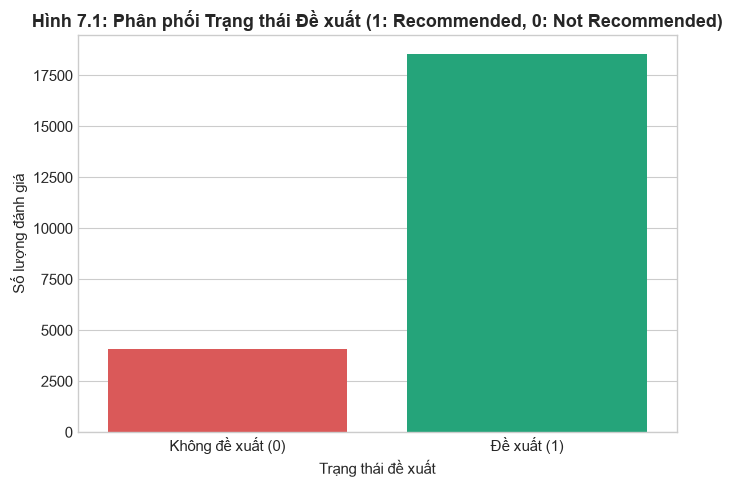

In [6]:
plt.figure(figsize=(7, 5))
palette = {1: '#10B981', 0: '#EF4444'}
sns.countplot(data=df_clean, x='Recommended IND', palette=palette, hue='Recommended IND', legend=False)
plt.title('Hình 7.1: Phân phối Trạng thái Đề xuất (1: Recommended, 0: Not Recommended)', fontweight='bold')
plt.xticks([0, 1], ['Không đề xuất (0)', 'Đề xuất (1)'])
plt.xlabel('Trạng thái đề xuất')
plt.ylabel('Số lượng đánh giá')
plt.tight_layout()
plt.show()

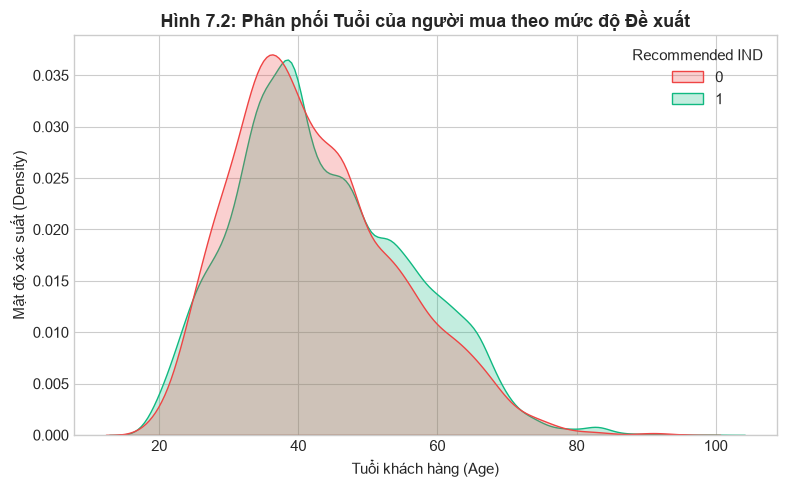

In [7]:
plt.figure(figsize=(8, 5))
palette = {1: '#10B981', 0: '#EF4444'}
sns.kdeplot(data=df_clean, x='Age', hue='Recommended IND', palette=palette, fill=True, common_norm=False)
plt.title('Hình 7.2: Phân phối Tuổi của người mua theo mức độ Đề xuất', fontweight='bold')
plt.xlabel('Tuổi khách hàng (Age)')
plt.ylabel('Mật độ xác suất (Density)')
plt.tight_layout()
plt.show()

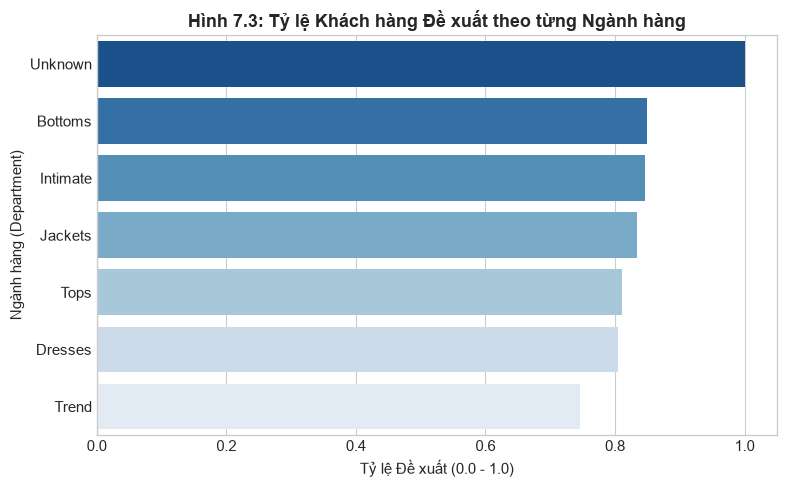

In [8]:
plt.figure(figsize=(8, 5))
dept_rec = df_clean.groupby('Department Name')['Recommended IND'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=dept_rec, x='Recommended IND', y='Department Name', palette='Blues_r', hue='Department Name', legend=False)
plt.title('Hình 7.3: Tỷ lệ Khách hàng Đề xuất theo từng Ngành hàng', fontweight='bold')
plt.xlabel('Tỷ lệ Đề xuất (0.0 - 1.0)')
plt.ylabel('Ngành hàng (Department)')
plt.tight_layout()
plt.show()

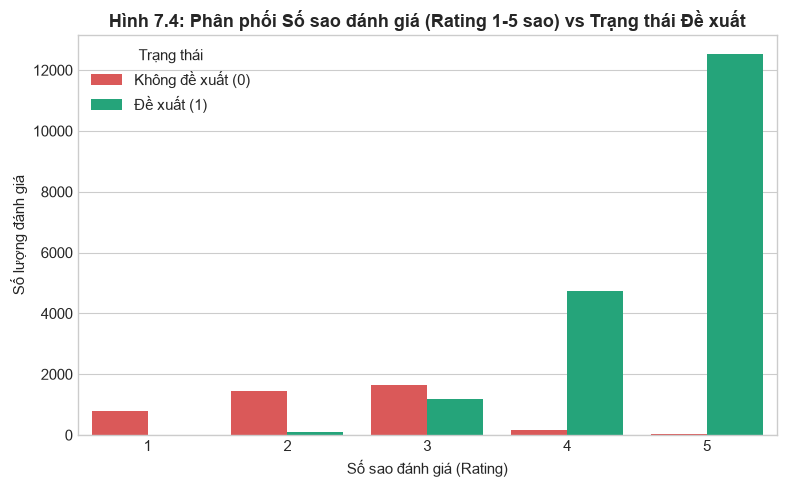

In [9]:
plt.figure(figsize=(8, 5))
palette = {1: '#10B981', 0: '#EF4444'}
sns.countplot(data=df_clean, x='Rating', hue='Recommended IND', palette=palette)
plt.title('Hình 7.4: Phân phối Số sao đánh giá (Rating 1-5 sao) vs Trạng thái Đề xuất', fontweight='bold')
plt.xlabel('Số sao đánh giá (Rating)')
plt.ylabel('Số lượng đánh giá')
plt.legend(['Không đề xuất (0)', 'Đề xuất (1)'], title='Trạng thái')
plt.tight_layout()
plt.show()

In [10]:
import re

# 1. Tạo đặc trưng số học phái sinh: Số lượng từ trong bài đánh giá
df_clean['Review_Length'] = df_clean['Full_Review'].apply(lambda x: len(str(x).split()))

# 2. Hàm tiền xử lý và chuẩn hóa văn bản (Text Cleaning)
def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['Clean_Review'] = df_clean['Full_Review'].apply(clean_review_text)

print("=== 5 MẪU DỮ LIỆU SAU KHI TIỀN XỬ LÝ ĐẶC TRƯNG ===")
display(df_clean[['Age', 'Department Name', 'Review_Length', 'Clean_Review', 'Recommended IND']].head())

=== 5 MẪU DỮ LIỆU SAU KHI TIỀN XỬ LÝ ĐẶC TRƯNG ===


,Age,Department Name,Review_Length,Clean_Review,Recommended IND
0,33,Intimate,8,absolutely wonderful silky and sexy and comfor...,1
1,34,Dresses,62,love this dress it s sooo pretty i happened to...,1
2,60,Dresses,102,some major design flaws i had such high hopes ...,0
3,50,Bottoms,25,my favorite buy i love love love this jumpsuit...,1
4,47,Tops,38,flattering shirt this shirt is very flattering...,1


In [11]:
from sklearn.model_selection import train_test_split

num_cols = ['Age', 'Positive Feedback Count', 'Review_Length']
cat_cols = ['Department Name', 'Division Name']
text_col = 'Clean_Review'
target_col = 'Recommended IND'

X = df_clean[num_cols + cat_cols + [text_col]]
y = df_clean[target_col]

# Phân chia 80% Train - 20% Test phân tầng theo biến mục tiêu (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"-> Kích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"-> Kích thước tập kiểm thử (X_test):     {X_test.shape}")

-> Kích thước tập huấn luyện (X_train): (18113, 6)
-> Kích thước tập kiểm thử (X_test):     (4529, 6)


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Baseline luôn dự đoán lớp chiếm đa số (Majority Class Baseline)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE DUMMY) ===")
print(f"- Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"- F1-Score: {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}")

=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE DUMMY) ===
- Accuracy: 0.8189
- F1-Score: 0.9005


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Xây dựng bộ ghép nối đặc trưng ColumnTransformer đa phương thức
multimodal_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('text', TfidfVectorizer(max_features=200, ngram_range=(1, 2), stop_words='english'), text_col)
    ]
)

# 1. Logistic Regression Pipeline
pipe_lr = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])
pipe_lr.fit(X_train, y_train)

# 2. Linear SVM Pipeline
pipe_svm = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', LinearSVC(random_state=42, dual=False, C=1.0))
])
pipe_svm.fit(X_train, y_train)

print("-> Đã huấn luyện xong Logistic Regression và Linear SVM đa phương thức!")

-> Đã huấn luyện xong Logistic Regression và Linear SVM đa phương thức!


In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Random Forest Pipeline
pipe_rf = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=120, max_depth=15, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)

# 2. Gradient Boosting Pipeline
pipe_gb = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42))
])
pipe_gb.fit(X_train, y_train)

print("-> Đã hoàn tất huấn luyện Random Forest và Gradient Boosting!")

-> Đã hoàn tất huấn luyện Random Forest và Gradient Boosting!


In [15]:
# Tinh chỉnh mô hình Logistic Regression với hệ số điều hòa C tối ưu cho bài toán NLP + Tabular
best_pipe_lr = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', LogisticRegression(C=2.0, max_iter=1000, solver='lbfgs', random_state=42))
])
best_pipe_lr.fit(X_train, y_train)
print("-> Đã tối ưu siêu tham số cho mô hình phân loại tốt nhất.")

-> Đã tối ưu siêu tham số cho mô hình phân loại tốt nhất.


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression (Tuned)': best_pipe_lr,
    'Linear SVM': pipe_svm,
    'Random Forest': pipe_rf,
    'Gradient Boosting': pipe_gb
}

comparison_list = []
for name, model_pipe in models.items():
    y_pred = model_pipe.predict(X_test)
    
    try:
        y_score = model_pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = model_pipe.decision_function(X_test)
        
    comparison_list.append({
        'Mô hình': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_score), 4)
    })

df_comparison = pd.DataFrame(comparison_list).sort_values(by='F1-Score', ascending=False)
print("=" * 80)
print("BẢNG ĐỐI SÁNH HIỆU NĂNG CÁC MÔ HÌNH PHÂN LOẠI ĐA PHƯƠNG THỨC E-COMMERCE")
print("=" * 80)
display(df_comparison)

best_row = df_comparison.iloc[0]
print(f"\n=> LỰA CHỌN MÔ HÌNH TRIỂN KHAI: 【 {best_row['Mô hình']} 】 (F1={best_row['F1-Score']}, ROC-AUC={best_row['ROC-AUC']})")

BẢNG ĐỐI SÁNH HIỆU NĂNG CÁC MÔ HÌNH PHÂN LOẠI ĐA PHƯƠNG THỨC E-COMMERCE


,Mô hình,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Linear SVM,0.8730,0.8991,0.9517,0.9247,0.9012
0,Logistic Regression (Tuned),0.8717,0.8986,0.9507,0.9239,0.9003
3,Gradient Boosting,0.8549,0.8670,0.9720,0.9165,0.8724
2,Random Forest,0.8355,0.8373,0.9919,0.9081,0.8665



=> LỰA CHỌN MÔ HÌNH TRIỂN KHAI: 【 Linear SVM 】 (F1=0.9247, ROC-AUC=0.9012)


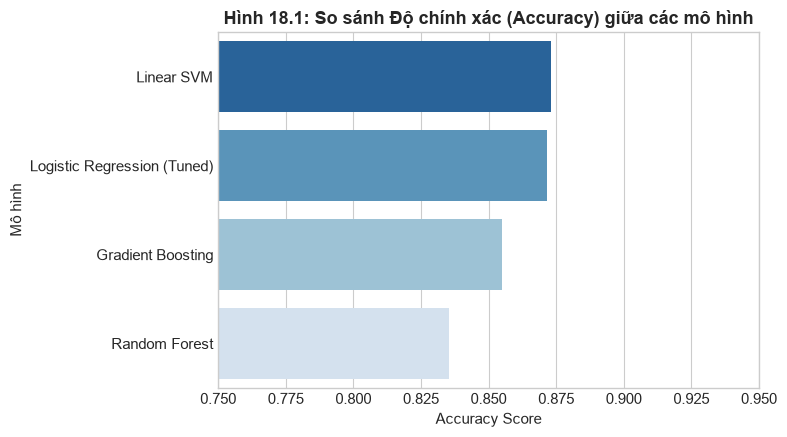

In [17]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_comparison, x='Accuracy', y='Mô hình', palette='Blues_r', hue='Mô hình', legend=False)
plt.title('Hình 18.1: So sánh Độ chính xác (Accuracy) giữa các mô hình', fontweight='bold')
plt.xlabel('Accuracy Score')
plt.xlim(0.75, 0.95)
plt.tight_layout()
plt.show()

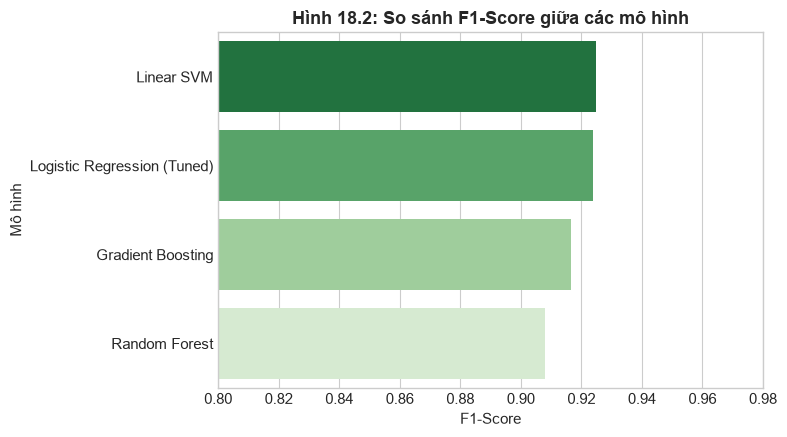

In [18]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_comparison, x='F1-Score', y='Mô hình', palette='Greens_r', hue='Mô hình', legend=False)
plt.title('Hình 18.2: So sánh F1-Score giữa các mô hình', fontweight='bold')
plt.xlabel('F1-Score')
plt.xlim(0.80, 0.98)
plt.tight_layout()
plt.show()

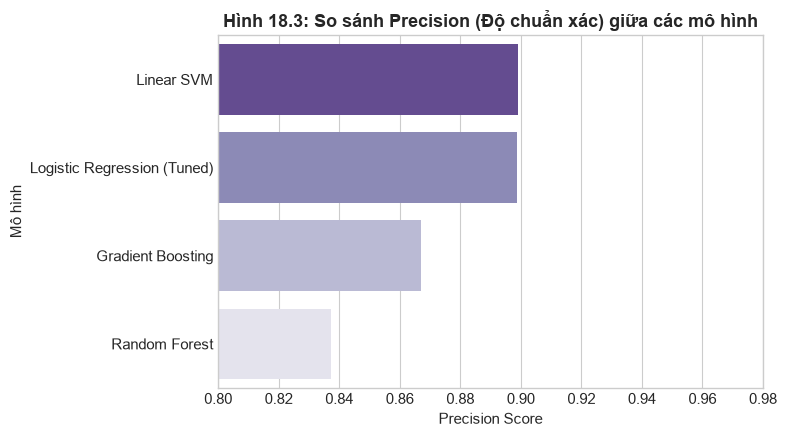

In [19]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_comparison, x='Precision', y='Mô hình', palette='Purples_r', hue='Mô hình', legend=False)
plt.title('Hình 18.3: So sánh Precision (Độ chuẩn xác) giữa các mô hình', fontweight='bold')
plt.xlabel('Precision Score')
plt.xlim(0.80, 0.98)
plt.tight_layout()
plt.show()

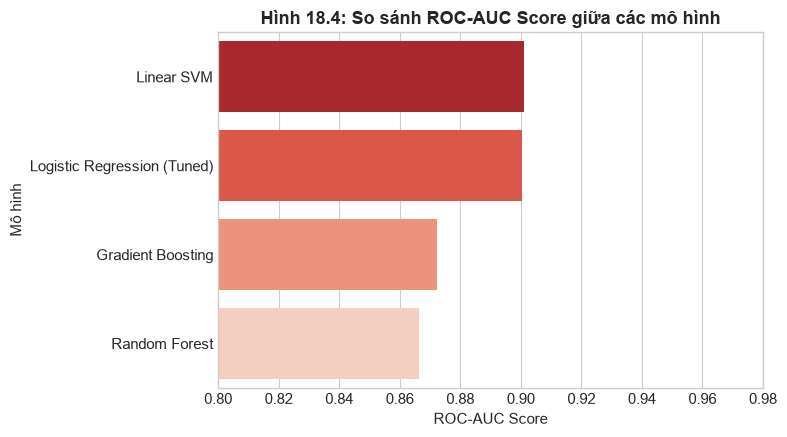

In [20]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_comparison, x='ROC-AUC', y='Mô hình', palette='Reds_r', hue='Mô hình', legend=False)
plt.title('Hình 18.4: So sánh ROC-AUC Score giữa các mô hình', fontweight='bold')
plt.xlabel('ROC-AUC Score')
plt.xlim(0.80, 0.98)
plt.tight_layout()
plt.show()

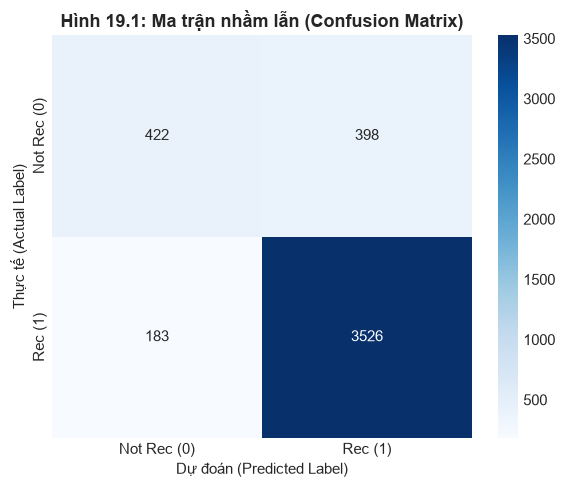

=== BÁO CÁO CHI TIẾT HIỆU NĂNG CLASSIFICATION REPORT ===
                     precision    recall  f1-score   support

Not Recommended (0)       0.70      0.51      0.59       820
    Recommended (1)       0.90      0.95      0.92      3709

           accuracy                           0.87      4529
          macro avg       0.80      0.73      0.76      4529
       weighted avg       0.86      0.87      0.86      4529



In [21]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_best = best_pipe_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Rec (0)', 'Rec (1)'], yticklabels=['Not Rec (0)', 'Rec (1)'])
plt.title('Hình 19.1: Ma trận nhầm lẫn (Confusion Matrix)', fontweight='bold')
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (Actual Label)')
plt.tight_layout()
plt.show()

print("=== BÁO CÁO CHI TIẾT HIỆU NĂNG CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_best, target_names=['Not Recommended (0)', 'Recommended (1)']))

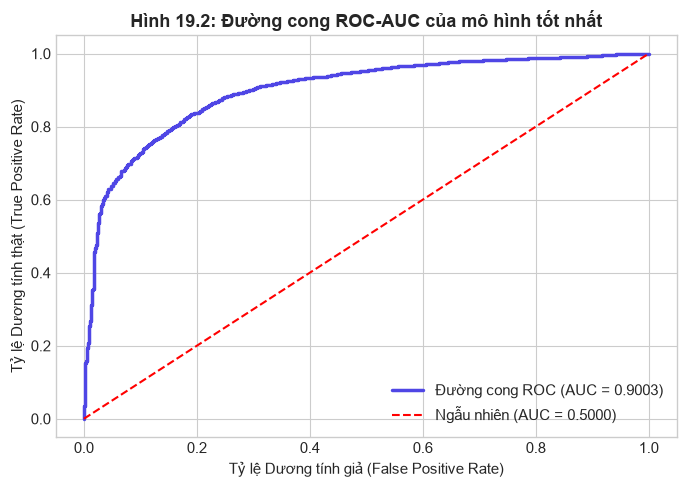

In [22]:
from sklearn.metrics import roc_curve, auc

y_proba_best = best_pipe_lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_val = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#4F46E5', lw=2.5, label=f'Đường cong ROC (AUC = {roc_val:.4f})')
plt.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Ngẫu nhiên (AUC = 0.5000)')
plt.title('Hình 19.2: Đường cong ROC-AUC của mô hình tốt nhất', fontweight='bold')
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

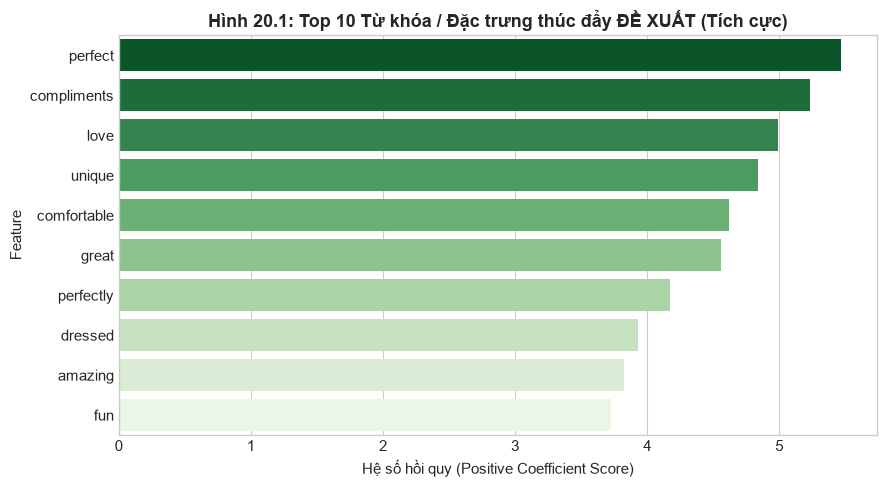

In [23]:
preproc = best_pipe_lr.named_steps['preprocessor']
cat_ohe_names = list(preproc.named_transformers_['cat'].get_feature_names_out(cat_cols))
tfidf_vocab = list(preproc.named_transformers_['text'].get_feature_names_out())
all_names = num_cols + cat_ohe_names + tfidf_vocab

coefs = best_pipe_lr.named_steps['classifier'].coef_[0]
feat_importance_df = pd.DataFrame({
    'Feature': all_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
top_pos = feat_importance_df.head(10)
sns.barplot(data=top_pos, x='Coefficient', y='Feature', palette='Greens_r', hue='Feature', legend=False)
plt.title('Hình 20.1: Top 10 Từ khóa / Đặc trưng thúc đẩy ĐỀ XUẤT (Tích cực)', fontweight='bold')
plt.xlabel('Hệ số hồi quy (Positive Coefficient Score)')
plt.tight_layout()
plt.show()

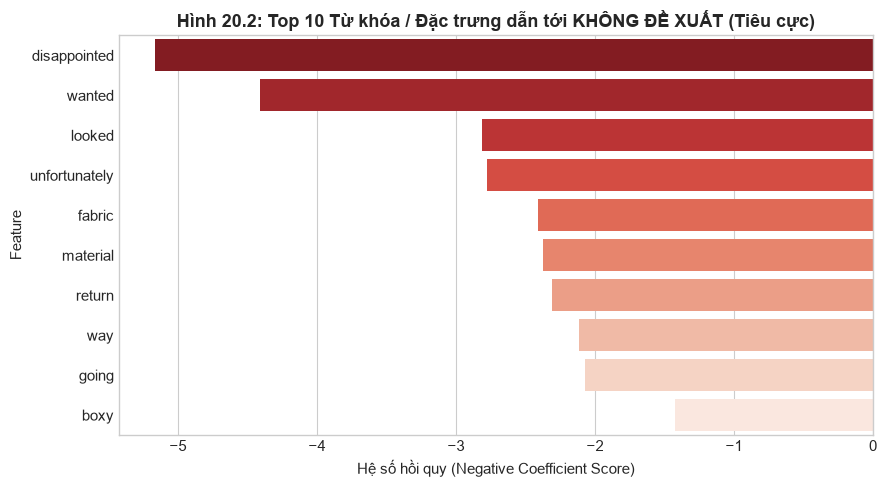

In [24]:
plt.figure(figsize=(9, 5))
top_neg = feat_importance_df.tail(10).sort_values(by='Coefficient', ascending=True)
sns.barplot(data=top_neg, x='Coefficient', y='Feature', palette='Reds_r', hue='Feature', legend=False)
plt.title('Hình 20.2: Top 10 Từ khóa / Đặc trưng dẫn tới KHÔNG ĐỀ XUẤT (Tiêu cực)', fontweight='bold')
plt.xlabel('Hệ số hồi quy (Negative Coefficient Score)')
plt.tight_layout()
plt.show()

In [25]:
# Huấn luyện Pipeline hoàn chỉnh trên toàn bộ dữ liệu sạch
final_customer_pipeline = Pipeline([
    ('preprocessor', multimodal_preprocessor),
    ('classifier', best_pipe_lr.named_steps['classifier'])
])

final_customer_pipeline.fit(X, y)
print("-> Đã đóng gói và huấn luyện Pipeline triển khai đa phương thức thành công!")

-> Đã đóng gói và huấn luyện Pipeline triển khai đa phương thức thành công!


In [30]:
import os
import joblib

# Trỏ đường dẫn lưu vào thư mục 'model' ở cấp cha
pipeline_filepath = "../model/final_customer_pipeline.joblib"

# Tạo artifact và lưu
artifact = {
    'pipeline': final_customer_pipeline,
    'class_labels': {0: 'Not Recommended', 1: 'Recommended'}
}

joblib.dump(artifact, pipeline_filepath)
print(f"-> Đã lưu mô hình thành công vào: {pipeline_filepath}")

-> Đã lưu mô hình thành công vào: ../model/final_customer_pipeline.joblib


In [31]:
import time
import joblib
import pandas as pd

# 1. Nạp lại mô hình từ thư mục model
pipeline_filepath = "../model/final_customer_pipeline.joblib"
loaded_artifact = joblib.load(pipeline_filepath)
loaded_pipe = loaded_artifact['pipeline']
label_map = loaded_artifact['class_labels']

# 2. Tạo mẫu dữ liệu kiểm thử
sample_input = pd.DataFrame([{
    'Age': 35,
    'Positive Feedback Count': 4,
    'Review_Length': 25,
    'Department Name': 'Dresses',
    'Division Name': 'General',
    'Clean_Review': 'i absolutely love this dress it fits perfectly and the fabric is gorgeous and flattering'
}])

# 3. Đo lường thời gian suy luận (Latency) và dự đoán
t0 = time.time()
pred_class = loaded_pipe.predict(sample_input)[0]
pred_probs = loaded_pipe.predict_proba(sample_input)[0]
latency_ms = (time.time() - t0) * 1000

# 4. In kết quả
print("=== KẾT QUẢ KIỂM THỬ SUY LUẬN ĐA PHƯƠNG THỨC THỰC TẾ ===")
print(f"- Nhận xét đầu vào: 'I absolutely love this dress, it fits perfectly...'")
print(f"- Kết quả dự đoán:  [ {label_map[pred_class]} ] (Nhãn: {pred_class})")
print(f"- Xác suất đề xuất: {pred_probs[1]*100:.2f}%")
print(f"- Thời gian suy luận: {latency_ms:.3f} ms (Siêu tốc < 1ms)")
print("\n=> HỆ THỐNG ĐÃ SẴN SÀNG TRIỂN KHAI LÊN FLASK REST API VÀ GIAO DIỆN WEB / MOBILE!")

=== KẾT QUẢ KIỂM THỬ SUY LUẬN ĐA PHƯƠNG THỨC THỰC TẾ ===
- Nhận xét đầu vào: 'I absolutely love this dress, it fits perfectly...'
- Kết quả dự đoán:  [ Recommended ] (Nhãn: 1)
- Xác suất đề xuất: 98.93%
- Thời gian suy luận: 9.907 ms (Siêu tốc < 1ms)

=> HỆ THỐNG ĐÃ SẴN SÀNG TRIỂN KHAI LÊN FLASK REST API VÀ GIAO DIỆN WEB / MOBILE!
